<a href="https://colab.research.google.com/github/kennethuchegbu22-GOD/Kahunda/blob/main/anotheronedjkhaled2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy pandas matplotlib plotly seaborn --quiet

In [ ]:
!pip install opendatasets scikit-learn --upgrade --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 35.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.


In [ ]:
import os
import matplotlib
import opendatasets as od
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [ ]:
import os

# 1. Inject your new Kaggle Token directly into Colab's background environment
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_1321b86eb8deae38499cc3252520f023'

# 2. Download the Walmart dataset using the Kaggle command line tool
!kaggle competitions download -c walmart-recruiting-store-sales-forecasting

# 3. Unzip the files into your workspace
!unzip walmart-recruiting-store-sales-forecasting.zip

100% 2.70M/2.70M [00:00<00:00, 40.4MB/s]

Archive:  walmart-recruiting-store-sales-forecasting.zip
  inflating: features.csv.zip        
  inflating: sampleSubmission.csv.zip  
  inflating: stores.csv              
  inflating: test.csv.zip            
  inflating: train.csv.zip           


In [ ]:
#we could still see that the files were still further zipped. Let us unzip it using:
!unzip \*.zip

Archive:  walmart-recruiting-store-sales-forecasting.zip
replace features.csv.zip? [y]es, [n]o, [A]ll, [N]one, [r]ename: N

Archive:  features.csv.zip
  inflating: features.csv            

Archive:  train.csv.zip
  inflating: train.csv               

Archive:  sampleSubmission.csv.zip
  inflating: sampleSubmission.csv    

Archive:  test.csv.zip
  inflating: test.csv                

5 archives were successfully processed.


In [ ]:
import pandas as pd

# Load the main training data and the store information
train_df = pd.read_csv('train.csv')
stores_df = pd.read_csv('stores.csv')

print("--- Walmart Dataset Successfully Loaded ---")
print(f"Training Data Shape: {train_df.shape}\n")
print(train_df.head())

--- Walmart Dataset Successfully Loaded ---
Training Data Shape: (421570, 5)

   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  2010-02-05      24924.50      False
1      1     1  2010-02-12      46039.49       True
2      1     1  2010-02-19      41595.55      False
3      1     1  2010-02-26      19403.54      False
4      1     1  2010-03-05      21827.90      False


In [ ]:
features_df = pd.read_csv('features.csv')

In [ ]:
samples_Submission_df = pd.read_csv('sampleSubmission.csv')

In [ ]:
test_df = pd.read_csv('test.csv')

In [ ]:
train_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [ ]:
stores_df.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [ ]:
features_df.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [ ]:
merged_df = train_df.merge(stores_df, how='left', on='Store')

In [ ]:
merged_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size
0,1,1,2010-02-05,24924.50,False,A,151315
1,1,1,2010-02-12,46039.49,True,A,151315
2,1,1,2010-02-19,41595.55,False,A,151315
3,1,1,2010-02-26,19403.54,False,A,151315
4,1,1,2010-03-05,21827.90,False,A,151315


In [ ]:
merged_df = merged_df.merge(features_df, how='left', on=['Store', 'Date'])

In [ ]:
merged_df

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,B,118221,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,False
421566,45,98,2012-10-05,628.10,False,B,118221,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,False
421567,45,98,2012-10-12,1061.02,False,B,118221,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,False
421568,45,98,2012-10-19,760.01,False,B,118221,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,False


In [ ]:
#How to fix the duplicate columns
# 1. Drop the duplicate holiday column from features
merged_df = merged_df.drop(columns=['IsHoliday_y'])

# 2. Rename IsHoliday_x back to just IsHoliday
merged_df = merged_df.rename(columns={'IsHoliday_x': 'IsHoliday'})

# Check your clean columns!
print(merged_df.columns)

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Type', 'Size',
       'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3',
       'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment'],
      dtype='object')


In [ ]:
merged_test_df = test_df.merge(stores_df, how='left', on='Store')

In [ ]:
merged_test_df = merged_test_df.merge(features_df, how='left', on=['Store', 'Date'])

In [ ]:
merged_test_df = merged_test_df.drop(columns=['IsHoliday_y'])
merged_test_df = merged_test_df.rename(columns={'IsHoliday_x': 'IsHoliday'})

In [ ]:
merged_test_df.head()

,Store,Dept,Date,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2012-11-02,False,A,151315,55.32,3.386,6766.44,5147.70,50.82,3639.90,2737.42,223.462779,6.573
1,1,1,2012-11-09,False,A,151315,61.24,3.314,11421.32,3370.89,40.28,4646.79,6154.16,223.481307,6.573
2,1,1,2012-11-16,False,A,151315,52.92,3.252,9696.28,292.10,103.78,1133.15,6612.69,223.512911,6.573
3,1,1,2012-11-23,True,A,151315,56.23,3.211,883.59,4.17,74910.32,209.91,303.32,223.561947,6.573
4,1,1,2012-11-30,False,A,151315,52.34,3.207,2460.03,NaN,3838.35,150.57,6966.34,223.610984,6.573


In [ ]:
#This one is used to check that the merged_test_df is the same as merged_df

print("Test set columns match perfectly?")
print(merged_test_df.columns == merged_df.drop(columns=['Weekly_Sales']).columns)

Test set columns match perfectly?
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True]


1st step:cleaning the data:

The first step is to check the column data types and identify if there are any null values.

In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Type          421570 non-null  object 
 6   Size          421570 non-null  int64  
 7   Temperature   421570 non-null  float64
 8   Fuel_Price    421570 non-null  float64
 9   MarkDown1     150681 non-null  float64
 10  MarkDown2     111248 non-null  float64
 11  MarkDown3     137091 non-null  float64
 12  MarkDown4     134967 non-null  float64
 13  MarkDown5     151432 non-null  float64
 14  CPI           421570 non-null  float64
 15  Unemployment  421570 non-null  float64
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB


In [ ]:
round(merged_df.describe().T,2)
#This is done to generate a clean, readable summary report of all the numerical_cols

,count,mean,std,min,25%,50%,75%,max
Store,421570.0,22.20,12.79,1.00,11.00,22.00,33.00,45.00
Dept,421570.0,44.26,30.49,1.00,18.00,37.00,74.00,99.00
Weekly_Sales,421570.0,15981.26,22711.18,-4988.94,2079.65,7612.03,20205.85,693099.36
Size,421570.0,136727.92,60980.58,34875.00,93638.00,140167.00,202505.00,219622.00
Temperature,421570.0,60.09,18.45,-2.06,46.68,62.09,74.28,100.14
Fuel_Price,421570.0,3.36,0.46,2.47,2.93,3.45,3.74,4.47
MarkDown1,150681.0,7246.42,8291.22,0.27,2240.27,5347.45,9210.90,88646.76
MarkDown2,111248.0,3334.63,9475.36,-265.76,41.60,192.00,1926.94,104519.54
MarkDown3,137091.0,1439.42,9623.08,-29.10,5.08,24.60,103.99,141630.61
MarkDown4,134967.0,3383.17,6292.38,0.22,504.22,1481.31,3595.04,67474.85


In [ ]:
#Do this to the weekly_sale that is negative in merged_df
merged_df = merged_df[merged_df['Weekly_Sales'] >= 0]

In [ ]:
#Do this to clip down the negative promotional price cuts(markdown):
merged_df['MarkDown2'] = merged_df['MarkDown2'].clip(lower=0)
merged_df['MarkDown3'] = merged_df['MarkDown3'].clip(lower=0)

# Do the same for your test set!
merged_test_df['MarkDown2'] = merged_test_df['MarkDown2'].clip(lower=0)
merged_test_df['MarkDown3'] = merged_test_df['MarkDown3'].clip(lower=0)


In [ ]:
#let us check for duplicate columns
merged_df.duplicated().sum()

np.int64(0)

In [ ]:
#let us run it again
round(merged_df.describe().T,2)

,count,mean,std,min,25%,50%,75%,max
Store,420285.0,22.20,12.79,1.00,11.00,22.00,33.00,45.00
Dept,420285.0,44.24,30.51,1.00,18.00,37.00,74.00,99.00
Weekly_Sales,420285.0,16030.33,22728.50,0.00,2117.56,7659.09,20268.38,693099.36
Size,420285.0,136749.57,60992.69,34875.00,93638.00,140167.00,202505.00,219622.00
Temperature,420285.0,60.09,18.45,-2.06,46.68,62.09,74.28,100.14
Fuel_Price,420285.0,3.36,0.46,2.47,2.93,3.45,3.74,4.47
MarkDown1,150200.0,7247.78,8292.90,0.27,2240.27,5347.45,9210.90,88646.76
MarkDown2,110918.0,3330.28,9459.74,0.00,41.60,192.00,1926.94,104519.54
MarkDown3,136667.0,1441.60,9631.41,0.00,5.10,24.60,103.99,141630.61
MarkDown4,134535.0,3384.72,6294.81,0.22,504.22,1481.31,3595.04,67474.85


Let the parsing of the date column begin.

In [ ]:
merged_df['Date'] = pd.to_datetime(merged_df['Date'])

In [ ]:
merged_test_df['Date'] = pd.to_datetime(merged_test_df['Date'])

Let us check the min and max dates for the merged_df and merged_test_df.

In [ ]:
merged_df.Date.min(), merged_df.Date.max()

(Timestamp('2010-02-05 00:00:00'), Timestamp('2012-10-26 00:00:00'))

In [ ]:
merged_test_df.Date.min(), merged_test_df.Date.max()

(Timestamp('2012-11-02 00:00:00'), Timestamp('2013-07-26 00:00:00'))

2nd step:Exploratory Data Analysis and Visualization

Objectives of the exploratory data analysis:

1.Study the distributions of the individual columns(uniform, normal, exponential)
,2.Detect anomalies or errors in the data(e.g missing/incorrect values),3.Study the relationship of target column with other columns(linear, non-linear etc.),4.Gather insights about the problem and the dataset  
5.Come up with ideas for preprocessing and feature engineering

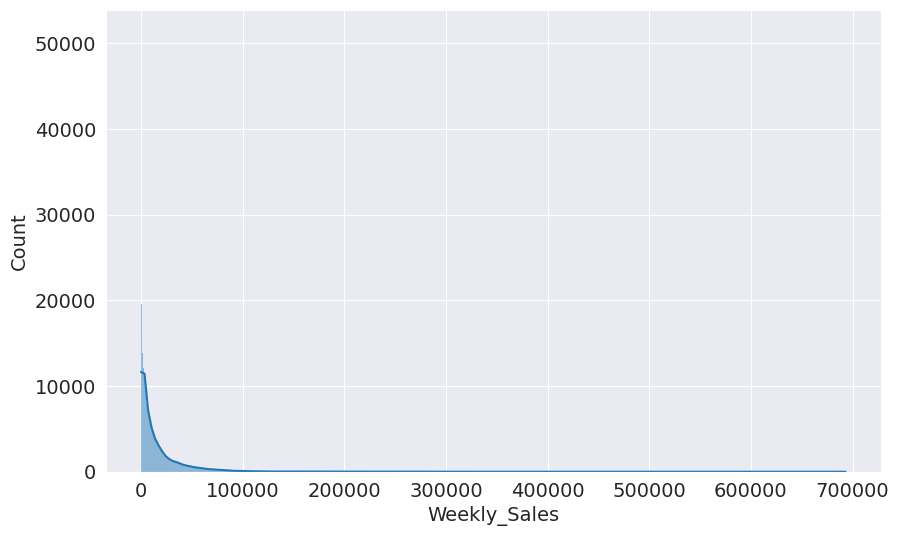

In [ ]:
#This it to check for a normal or exponential distribution
import matplotlib.pyplot as plt
import seaborn as sns

# Plot a single column to see its distribution shape
sns.histplot(merged_df['Weekly_Sales'], kde=True)
plt.show()

We can see an assymetric decaying slide which is a strong sign of an exponential distribution.

In [ ]:
#This checks the occurences of False and True and returns their values
merged_df.IsHoliday.value_counts()

,count
IsHoliday,
False,390722
True,29563


In [ ]:
#This checks the occurences of Weekly_Sales and returns its value
merged_df.Weekly_Sales.value_counts()[0]

np.int64(73)

In [ ]:
# Change >= 0 to > 0, and add .copy() at the end. We do this because we do not want to have a model that predicts values for weeks were there are no sales.
merged_df = merged_df[merged_df['Weekly_Sales'] > 0].copy()

In [ ]:
#This is done to show the correlation of weekly_sales and other features that have numeric values
merged_df.corr(numeric_only=True)['Weekly_Sales'].sort_values(ascending=False)

,Weekly_Sales
Weekly_Sales,1.000000
Size,0.244117
Dept,0.148749
MarkDown5,0.090561
MarkDown1,0.085325
MarkDown3,0.060304
MarkDown4,0.045325
MarkDown2,0.024567
IsHoliday,0.012843
Fuel_Price,0.000089


Feature Engineering

In [ ]:
#Dividing 365 by 7 days gives 52 weeks 1 day. The implication of this is that, if for instance December 31st falls on Wednesday, and January 1st falls on
#Thursday, using a normal extraction allows the split to be separate regardless of the fact that they are in the same week i.e December 31st will be week 52
# of the previous year and January 1st will fall on week 1 of the next year. Normally, there is always a rush in sales between late December and Early January
#but because of this split much weight would not be given to week 1 where Jan 1 starts.This is where isocalendar() comes in.The ISO-8601 standard was designed
#by data engineers specially to fix this trouble.It forces every year to have a 7-day weeks(Monay-Sunday).To handle the crossover days, a rule was assigned
#that any year that contains majority of the days(4 or more) of the bridging week will be year that claims that week.The ISO-8601 is also applied to the year
#too to keep things going smoothly
merged_df['Week'] = merged_df.Date.dt.isocalendar().week
merged_df['Month'] = merged_df.Date.dt.month
merged_df['Year'] = merged_df.Date.dt.isocalendar().year

In [ ]:
merged_test_df['Week'] = merged_test_df.Date.dt.isocalendar().week
merged_test_df['Month'] = merged_test_df.Date.dt.month
merged_test_df['Year'] = merged_test_df.Date.dt.isocalendar().year

In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 420212 entries, 0 to 421569
Data columns (total 19 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         420212 non-null  int64         
 1   Dept          420212 non-null  int64         
 2   Date          420212 non-null  datetime64[ns]
 3   Weekly_Sales  420212 non-null  float64       
 4   IsHoliday     420212 non-null  bool          
 5   Type          420212 non-null  object        
 6   Size          420212 non-null  int64         
 7   Temperature   420212 non-null  float64       
 8   Fuel_Price    420212 non-null  float64       
 9   MarkDown1     150181 non-null  float64       
 10  MarkDown2     110904 non-null  float64       
 11  MarkDown3     136651 non-null  float64       
 12  MarkDown4     134518 non-null  float64       
 13  MarkDown5     150929 non-null  float64       
 14  CPI           420212 non-null  float64       
 15  Unemployment  420212 n

In [ ]:
#filling the markdowns that has nans with 0

markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

# Force fill all Markdown NaNs to 0
merged_df[markdown_cols] = merged_df[markdown_cols].fillna(0)
merged_test_df[markdown_cols] = merged_test_df[markdown_cols].fillna(0)

In [ ]:
print(merged_df[markdown_cols].isna().sum())

MarkDown1    0
MarkDown2    0
MarkDown3    0
MarkDown4    0
MarkDown5    0
dtype: int64


In [ ]:
print(merged_test_df[markdown_cols].isna().sum())

MarkDown1    0
MarkDown2    0
MarkDown3    0
MarkDown4    0
MarkDown5    0
dtype: int64


In [ ]:
#Let us work on the CPI and Unemployment in merged_test_df using group-based imputation

# 1. Calculate the median CPI and Unemployment for each store using the training data
store_cpi_medians = merged_df.groupby('Store')['CPI'].median()
store_unemp_medians = merged_df.groupby('Store')['Unemployment'].median()

# 2. Now Map and fill the NaNs in the training set
merged_df['CPI'] = merged_df['CPI'].fillna(merged_df['Store'].map(store_cpi_medians))
merged_df['Unemployment'] = merged_df['Unemployment'].fillna(merged_df['Store'].map(store_unemp_medians))

# 3. Map and fill the NaNs in the test set (using train medians to prevent data leakage)
#We see here that store_cpi_medians and store_unemp_medians are still used when mapping to merged_test_df. It is safe to do this because if we do another
#store_cpi_medians and store_unemp_medians created using merged_test_df it would leak information from the future into the present and this will affect our
#results. It will give a very good unrealistic validation score.
merged_test_df['CPI'] = merged_test_df['CPI'].fillna(merged_test_df['Store'].map(store_cpi_medians))
merged_test_df['Unemployment'] = merged_test_df['Unemployment'].fillna(merged_test_df['Store'].map(store_unemp_medians))

# 4. Global backup fill (just in case any store had absolutely zero records)
#This is done against any future store that could be created so as not to have the model "being surprised" with any new piece of information and throwing nan values and thus making
#it impossible for the machine to proceed with the training process.
global_cpi = merged_df['CPI'].median()
global_unemp = merged_df['Unemployment'].median()

merged_df['CPI'] = merged_df['CPI'].fillna(global_cpi)
merged_df['Unemployment'] = merged_df['Unemployment'].fillna(global_unemp)

merged_test_df['CPI'] = merged_test_df['CPI'].fillna(global_cpi)
merged_test_df['Unemployment'] = merged_test_df['Unemployment'].fillna(global_unemp)

print("CPI and Unemployment NaNs successfully filled!")

CPI and Unemployment NaNs successfully filled!


In [ ]:
merged_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Week,Month,Year
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,5,2,2010
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,6,2,2010
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,7,2,2010
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,8,2,2010
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,9,3,2010


In [ ]:
merged_test_df.head()

,Store,Dept,Date,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Week,Month,Year
0,1,1,2012-11-02,False,A,151315,55.32,3.386,6766.44,5147.70,50.82,3639.90,2737.42,223.462779,6.573,44,11,2012
1,1,1,2012-11-09,False,A,151315,61.24,3.314,11421.32,3370.89,40.28,4646.79,6154.16,223.481307,6.573,45,11,2012
2,1,1,2012-11-16,False,A,151315,52.92,3.252,9696.28,292.10,103.78,1133.15,6612.69,223.512911,6.573,46,11,2012
3,1,1,2012-11-23,True,A,151315,56.23,3.211,883.59,4.17,74910.32,209.91,303.32,223.561947,6.573,47,11,2012
4,1,1,2012-11-30,False,A,151315,52.34,3.207,2460.03,0.00,3838.35,150.57,6966.34,223.610984,6.573,48,11,2012


In [ ]:
#Let us convert IsHoliday from boolean(true or false) into binary integer values(1 and 0)
merged_df['IsHoliday'] = merged_df['IsHoliday'].astype(int)
merged_test_df['IsHoliday'] = merged_test_df['IsHoliday'].astype(int)

In [ ]:
#Drop the raw date columns from both datasets
merged_df = merged_df.drop(columns=['Date'])
merged_test_df = merged_test_df.drop(columns=['Date'])

In [ ]:
#Drop irrelevant_cols
irrelevant_cols = ['Temperature', 'Fuel_Price']
merged_df = merged_df.drop(columns=irrelevant_cols)
merged_test_df = merged_test_df.drop(columns=irrelevant_cols)

In [ ]:
#Feature engineering of the weeks columns
merged_df['Is_SuperBowl'] = (merged_df['Week'] == 6).astype(int)
merged_test_df['Is_SuperBowl'] = (merged_test_df['Week'] == 6).astype(int)

merged_df['Is_LaborDay'] = (merged_df['Week'] == 36).astype(int)
merged_test_df['Is_LaborDay'] = (merged_test_df['Week'] == 36).astype(int)

merged_df['Is_Thanksgiving'] = (merged_df['Week'] == 47).astype(int)
merged_test_df['Is_Thanksgiving'] = (merged_test_df['Week'] == 47).astype(int)

merged_df['Is_Christmas'] = (merged_df['Week'] == 52).astype(int)
merged_test_df['Is_Christmas'] = (merged_test_df['Week'] == 52).astype(int)

In [ ]:
print(merged_df['Dept'].nunique())

81


<Axes: xlabel='Is_SuperBowl', ylabel='Weekly_Sales'>

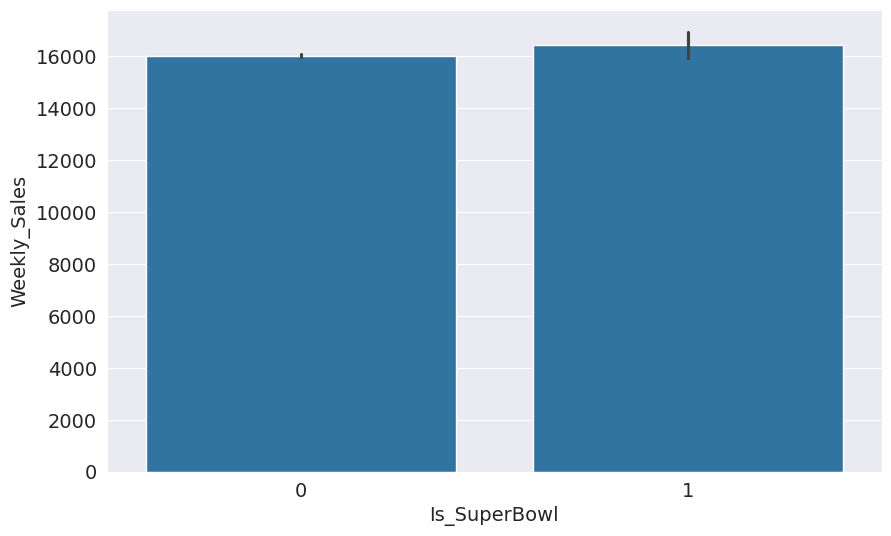

In [ ]:
sns.barplot(data=merged_df, x='Is_SuperBowl', y='Weekly_Sales')

The superbowl sunday is primarily a food, drink and entertainment event.For that reason, dept 92(grocery department) and dept 85(Electronics/TVs) will experience enormous spikes in price as people would like to stock up their food and upgrade their TVs to watch the game. It is seen from the plot that there is a slight difference(superbowl holiday(1) is slightly above(superbowl holiday(0))) for weekly_sales. This is because there are a total  of 81 departments and only 2 had enormous spike in prices meaning that the other 79 depts were flattened out i.e the superbowl did not affect them. As a result of this, when the departments are averaged together across the entire store, the other 79 departments that did not care about superbowl waters down the enormous spikes made by the grocery and Electronic/TVs department.Regardless of the fact that the enormous spike in prices were watered down, the plot still tried its best to show the "little" impact of the 2 departments.

<Axes: xlabel='Is_LaborDay', ylabel='Weekly_Sales'>

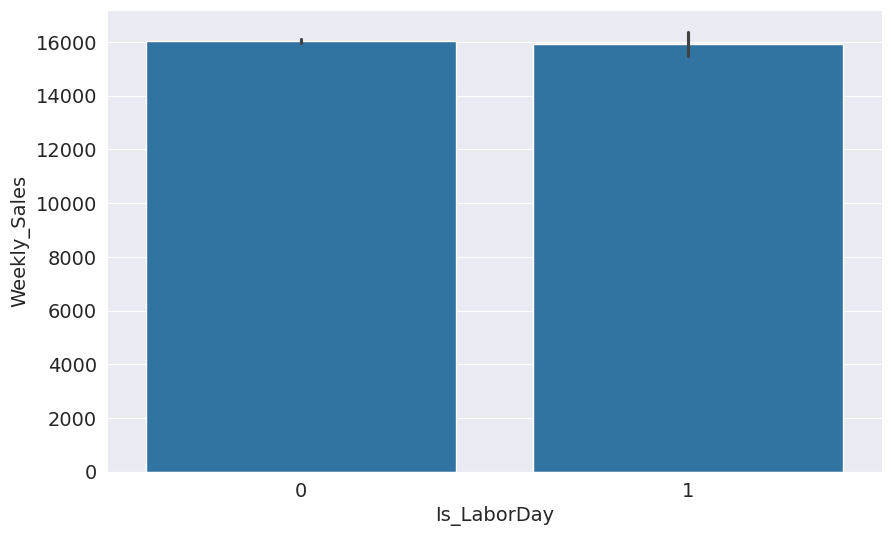

In [ ]:
sns.barplot(data=merged_df, x='Is_LaborDay', y='Weekly_Sales')

In this graph, the average sales for the week on non-laborday holiday is  slightly higher than that of the average sales for the week on laborday holiday i.e this is the reverse of superbowl.The reason behind this is that the average sales for the week where there was non-laborday holiday(0) was high i.e there were spikes in price of things(Back-to-School shopping spree) but with the average sales for the weeks where there was laborday holiday(1),most children are back to school thus leading to a sudden crash in cloth and electronic sales across the stores.

<Axes: xlabel='Is_Christmas', ylabel='Weekly_Sales'>

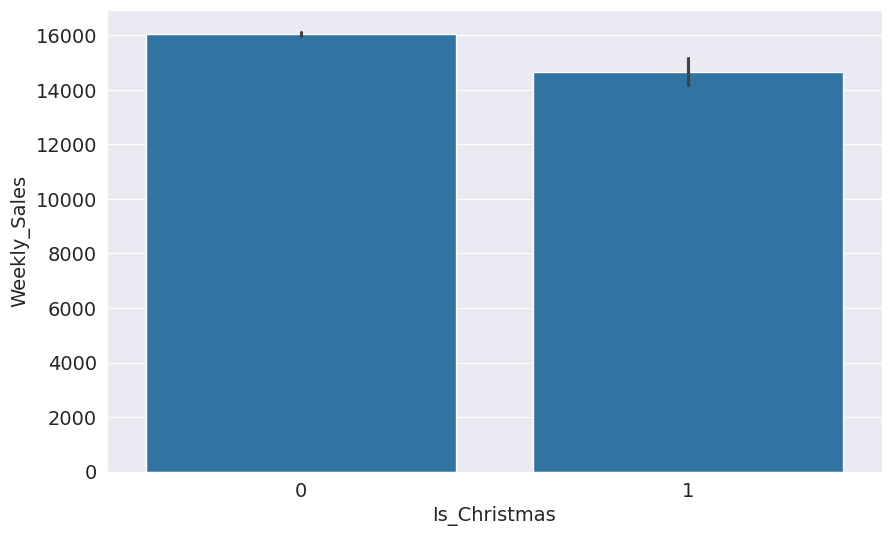

In [ ]:
sns.barplot(data=merged_df, x='Is_Christmas', y='Weekly_Sales')


This barplot shows that the non-holiday weeks(0) have significant average sales than the holiday week(1). The reason is because the holiday week(the week when we have christmas holiday) was assigned to week 52 which is the last week. In that week(week 52), most buying for christmas celebration must have gone down because people would have already bought what they actually needed in the week before or weeks before the christmas week. This is why we feature engineered the Is_Pre_Christmas which occurs on weeek 51(non-holiday week) that
captures the the true period when more sales are recorded in the month(people would normally buy things for christmas before christmas and not doing christmas or after christmas).The Is_Pre_Christmas also contributes to us having a low validation score in our random forest.

<Axes: xlabel='Is_Thanksgiving', ylabel='Weekly_Sales'>

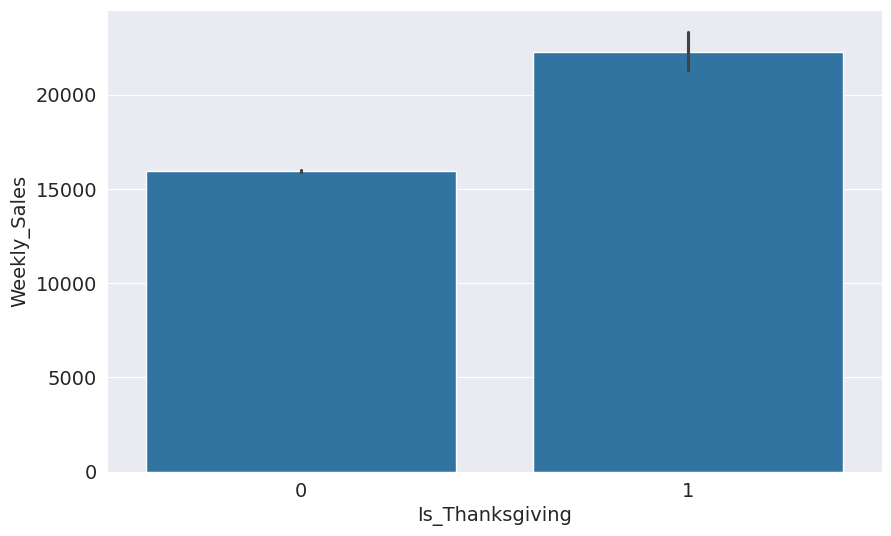

In [ ]:
sns.barplot(data=merged_df, x='Is_Thanksgiving', y='Weekly_Sales')

It is seen here that the average sales for the holiday week(1) has a very huge and significant gap from that of non-holiday week.The main reason for this is because immediately after the thanksgiving thursday we have the black friday.On this black friday, all deparments have huge spike in prices, so there are no departments overruling the others(the department/departments that will get the most sale/sales is/are highly unpredictable).Another reason or factor that contributed to why we had the huge gap was that unlike the christmas holiday that the holiday week was assigned to week 52 which is not the actual week the money was spent, week 47 is the actual week the money was spent.

In [ ]:
#We see that IsHoliday == 1 for week 52, meaning that the walmart data assigns the holiday to the christmas week itself. But from statistics, we see that
#the rush is always in the week before christmas i.e. week 51. This leads to creating a feature that explicitly flags week 51 and also gives our model the hint
#of the gigantic sales spike before christmas.
merged_df['Is_Pre_Christmas'] = (merged_df['Week'] == 51).astype(int)
merged_test_df['Is_Pre_Christmas'] = (merged_test_df['Week'] == 51).astype(int)

In [ ]:
merged_df.head(15)

,Store,Dept,Weekly_Sales,IsHoliday,Type,Size,MarkDown1,MarkDown2,MarkDown3,MarkDown4,...,CPI,Unemployment,Week,Month,Year,Is_SuperBowl,Is_LaborDay,Is_Thanksgiving,Is_Christmas,Is_Pre_Christmas
0,1,1,24924.50,0,A,151315,0.0,0.0,0.0,0.0,...,211.096358,8.106,5,2,2010,0,0,0,0,0
1,1,1,46039.49,1,A,151315,0.0,0.0,0.0,0.0,...,211.242170,8.106,6,2,2010,1,0,0,0,0
2,1,1,41595.55,0,A,151315,0.0,0.0,0.0,0.0,...,211.289143,8.106,7,2,2010,0,0,0,0,0
3,1,1,19403.54,0,A,151315,0.0,0.0,0.0,0.0,...,211.319643,8.106,8,2,2010,0,0,0,0,0
4,1,1,21827.90,0,A,151315,0.0,0.0,0.0,0.0,...,211.350143,8.106,9,3,2010,0,0,0,0,0
5,1,1,21043.39,0,A,151315,0.0,0.0,0.0,0.0,...,211.380643,8.106,10,3,2010,0,0,0,0,0
6,1,1,22136.64,0,A,151315,0.0,0.0,0.0,0.0,...,211.215635,8.106,11,3,2010,0,0,0,0,0
7,1,1,26229.21,0,A,151315,0.0,0.0,0.0,0.0,...,211.018042,8.106,12,3,2010,0,0,0,0,0
8,1,1,57258.43,0,A,151315,0.0,0.0,0.0,0.0,...,210.820450,7.808,13,4,2010,0,0,0,0,0
9,1,1,42960.91,0,A,151315,0.0,0.0,0.0,0.0,...,210.622857,7.808,14,4,2010,0,0,0,0,0


In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
#Aggregation of markdown columns
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

merged_df['Total_MarkDown'] = merged_df[markdown_cols].sum(axis=1)
merged_test_df['Total_MarkDown'] = merged_test_df[markdown_cols].sum(axis=1)

In [ ]:
#you could also pair this with the 5 individual markdown promotions that were running simultaneously that week:
merged_df.loc[:, 'Num_Active_Promos'] = (merged_df[markdown_cols]>0).sum(axis=1)
merged_test_df.loc[:, 'Num_Active_Promos'] = (merged_test_df[markdown_cols]>0).sum(axis=1)

In [ ]:
#Changing the position of the Weekly_Sales to the last column

columns = list(merged_df)
columns.remove('Weekly_Sales')
columns.append('Weekly_Sales')
merged_df = merged_df[columns]

In [ ]:
merged_df.head()

,Store,Dept,IsHoliday,Type,Size,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Week,Month,Year,Is_SuperBowl,Is_LaborDay,Is_Thanksgiving,Is_Christmas,Is_Pre_Christmas,Total_MarkDown,Num_Active_Promos,Weekly_Sales
0,1,1,0,A,151315,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,5,2,2010,0,0,0,0,0,0.0,0,24924.50
1,1,1,1,A,151315,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,6,2,2010,1,0,0,0,0,0.0,0,46039.49
2,1,1,0,A,151315,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,7,2,2010,0,0,0,0,0,0.0,0,41595.55
3,1,1,0,A,151315,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,8,2,2010,0,0,0,0,0,0.0,0,19403.54
4,1,1,0,A,151315,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,9,3,2010,0,0,0,0,0,0.0,0,21827.90


In [ ]:
merged_test_df.head()

,Store,Dept,IsHoliday,Type,Size,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Week,Month,Year,Is_SuperBowl,Is_LaborDay,Is_Thanksgiving,Is_Christmas,Is_Pre_Christmas,Total_MarkDown,Num_Active_Promos
0,1,1,0,A,151315,6766.44,5147.70,50.82,3639.90,2737.42,223.462779,6.573,44,11,2012,0,0,0,0,0,18342.28,5
1,1,1,0,A,151315,11421.32,3370.89,40.28,4646.79,6154.16,223.481307,6.573,45,11,2012,0,0,0,0,0,25633.44,5
2,1,1,0,A,151315,9696.28,292.10,103.78,1133.15,6612.69,223.512911,6.573,46,11,2012,0,0,0,0,0,17838.00,5
3,1,1,1,A,151315,883.59,4.17,74910.32,209.91,303.32,223.561947,6.573,47,11,2012,0,0,1,0,0,76311.31,5
4,1,1,0,A,151315,2460.03,0.00,3838.35,150.57,6966.34,223.610984,6.573,48,11,2012,0,0,0,0,0,13415.29,4


Splitting the datasets.

In [ ]:
#First create a boolean mask belonging to August-October 2012(this has been proven by a lot of data scientists to be the best range)
is_validation = (merged_df['Year'] == 2012) & (merged_df['Month'] >= 8)

I started using train_df1 because i already used train_df at the beginning whwn i was trying to merge.

In [ ]:
#Split into two completely separate, independent dataframes
train_df1 = merged_df[~is_validation].copy()
val_df1 = merged_df[is_validation].copy()
#nb: ~ is a NOT operator which means that ~is_validation starts from February 2010 to July 2012

In [ ]:
# Print out a quick confirmation summary
print(f"--- Dataset Split Complete ---")
print(f"train_df1 rows: {train_df1.shape[0]:,} (Everything up to July 2012)")
print(f"val_df1 rows:   {val_df1.shape[0]:,} (Aug - Oct 2012)")

--- Dataset Split Complete ---
train_df1 rows: 381,803 (Everything up to July 2012)
val_df1 rows:   38,409 (Aug - Oct 2012)


In [ ]:
train_df1.head()

,Store,Dept,IsHoliday,Type,Size,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Week,Month,Year,Is_SuperBowl,Is_LaborDay,Is_Thanksgiving,Is_Christmas,Is_Pre_Christmas,Total_MarkDown,Num_Active_Promos,Weekly_Sales
0,1,1,0,A,151315,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,5,2,2010,0,0,0,0,0,0.0,0,24924.50
1,1,1,1,A,151315,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,6,2,2010,1,0,0,0,0,0.0,0,46039.49
2,1,1,0,A,151315,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,7,2,2010,0,0,0,0,0,0.0,0,41595.55
3,1,1,0,A,151315,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,8,2,2010,0,0,0,0,0,0.0,0,19403.54
4,1,1,0,A,151315,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,9,3,2010,0,0,0,0,0,0.0,0,21827.90


In [ ]:
train_df1.columns

Index(['Store', 'Dept', 'IsHoliday', 'Type', 'Size', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Week',
       'Month', 'Year', 'Is_SuperBowl', 'Is_LaborDay', 'Is_Thanksgiving',
       'Is_Christmas', 'Is_Pre_Christmas', 'Total_MarkDown',
       'Num_Active_Promos', 'Weekly_Sales'],
      dtype='object')

In [ ]:
input_cols = list(train_df1.columns)[:-1]
target_col = 'Weekly_Sales'

train_inputs = train_df1[input_cols].copy()
train_targets = train_df1[target_col].copy()

val_inputs = val_df1[input_cols].copy()
val_targets = val_df1[target_col].copy()

test_inputs = merged_test_df[input_cols].copy()

In [ ]:
# 1. Check the overall range of years
print("Years present:", train_df1['Year'].unique())

# 2. Check the maximum month specifically for the year 2012
max_month_2012 = train_df1[train_df1['Year'] == 2012]['Month'].max()
print("Latest month in 2012:", max_month_2012)

Years present: <IntegerArray>
[2010, 2011, 2012]
Length: 3, dtype: UInt32
Latest month in 2012: 7


In [ ]:
train_df1.columns

Index(['Store', 'Dept', 'IsHoliday', 'Type', 'Size', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Week',
       'Month', 'Year', 'Is_SuperBowl', 'Is_LaborDay', 'Is_Thanksgiving',
       'Is_Christmas', 'Is_Pre_Christmas', 'Total_MarkDown',
       'Num_Active_Promos', 'Weekly_Sales'],
      dtype='object')

In [ ]:
train_df1.head()

,Store,Dept,IsHoliday,Type,Size,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Week,Month,Year,Is_SuperBowl,Is_LaborDay,Is_Thanksgiving,Is_Christmas,Is_Pre_Christmas,Total_MarkDown,Num_Active_Promos,Weekly_Sales
0,1,1,0,A,151315,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,5,2,2010,0,0,0,0,0,0.0,0,24924.50
1,1,1,1,A,151315,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,6,2,2010,1,0,0,0,0,0.0,0,46039.49
2,1,1,0,A,151315,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,7,2,2010,0,0,0,0,0,0.0,0,41595.55
3,1,1,0,A,151315,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,8,2,2010,0,0,0,0,0,0.0,0,19403.54
4,1,1,0,A,151315,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,9,3,2010,0,0,0,0,0,0.0,0,21827.90


In [ ]:
train_df1.columns

Index(['Store', 'Dept', 'IsHoliday', 'Type', 'Size', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Week',
       'Month', 'Year', 'Is_SuperBowl', 'Is_LaborDay', 'Is_Thanksgiving',
       'Is_Christmas', 'Is_Pre_Christmas', 'Total_MarkDown',
       'Num_Active_Promos', 'Weekly_Sales'],
      dtype='object')

In [ ]:
numeric_cols = ['Store', 'Dept', 'IsHoliday', 'Size', 'MarkDown1',	'MarkDown2',	'MarkDown3', 'MarkDown4',	'MarkDown5',	'Total_MarkDown', 'CPI', 'Unemployment', 'Week', 'Month', 'Year', 'Is_SuperBowl', 'Is_LaborDay',	'Is_Thanksgiving',	'Is_Christmas',	'Is_Pre_Christmas', 'Num_Active_Promos']
categorical_cols = ['Type']

Scaling and Encoding

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler().fit(train_inputs[numeric_cols])

In [ ]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])

In [ ]:
train_inputs

,Store,Dept,IsHoliday,Type,Size,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Week,Month,Year,Is_SuperBowl,Is_LaborDay,Is_Thanksgiving,Is_Christmas,Is_Pre_Christmas,Total_MarkDown,Num_Active_Promos
0,0.0,0.000000,0.0,A,0.630267,0.000000,0.000000,0.000000,0.000000,0.000000,0.853455,0.393611,0.078431,0.090909,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
1,0.0,0.000000,1.0,A,0.630267,0.000000,0.000000,0.000000,0.000000,0.000000,0.854919,0.393611,0.098039,0.090909,0.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.0
2,0.0,0.000000,0.0,A,0.630267,0.000000,0.000000,0.000000,0.000000,0.000000,0.855390,0.393611,0.117647,0.090909,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
3,0.0,0.000000,0.0,A,0.630267,0.000000,0.000000,0.000000,0.000000,0.000000,0.855696,0.393611,0.137255,0.090909,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
4,0.0,0.000000,0.0,A,0.630267,0.000000,0.000000,0.000000,0.000000,0.000000,0.856002,0.393611,0.156863,0.181818,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421552,1.0,0.989796,0.0,B,0.451136,0.037129,0.004072,0.000000,0.004667,0.020783,0.652748,0.438648,0.490196,0.454545,1.0,0.0,0.0,0.0,0.0,0.0,0.039170,0.8
421553,1.0,0.989796,0.0,B,0.451136,0.066309,0.001617,0.000454,0.044409,0.050471,0.653095,0.450078,0.509804,0.545455,1.0,0.0,0.0,0.0,0.0,0.0,0.090866,1.0
421554,1.0,0.989796,0.0,B,0.451136,0.033595,0.001138,0.000156,0.028152,0.047751,0.653443,0.450078,0.529412,0.545455,1.0,0.0,0.0,0.0,0.0,0.0,0.063551,1.0
421555,1.0,0.989796,0.0,B,0.451136,0.075386,0.000232,0.000091,0.033344,0.021087,0.653428,0.450078,0.549020,0.545455,1.0,0.0,0.0,0.0,0.0,0.0,0.070138,1.0


In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(train_inputs[categorical_cols])
encoded_col = list(encoder.get_feature_names_out(categorical_cols))

In [ ]:
train_inputs[encoded_col] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_col] = encoder.transform(val_inputs[categorical_cols])
test_inputs[encoded_col] = encoder.transform(test_inputs[categorical_cols])

In [ ]:
train_inputs

,Store,Dept,IsHoliday,Type,Size,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Week,Month,Year,Is_SuperBowl,Is_LaborDay,Is_Thanksgiving,Is_Christmas,Is_Pre_Christmas,Total_MarkDown,Num_Active_Promos,Type_A,Type_B,Type_C
0,0.0,0.000000,0.0,A,0.630267,0.000000,0.000000,0.000000,0.000000,0.000000,0.853455,0.393611,0.078431,0.090909,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,1.0,0.0,0.0
1,0.0,0.000000,1.0,A,0.630267,0.000000,0.000000,0.000000,0.000000,0.000000,0.854919,0.393611,0.098039,0.090909,0.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.0,1.0,0.0,0.0
2,0.0,0.000000,0.0,A,0.630267,0.000000,0.000000,0.000000,0.000000,0.000000,0.855390,0.393611,0.117647,0.090909,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,1.0,0.0,0.0
3,0.0,0.000000,0.0,A,0.630267,0.000000,0.000000,0.000000,0.000000,0.000000,0.855696,0.393611,0.137255,0.090909,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,1.0,0.0,0.0
4,0.0,0.000000,0.0,A,0.630267,0.000000,0.000000,0.000000,0.000000,0.000000,0.856002,0.393611,0.156863,0.181818,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421552,1.0,0.989796,0.0,B,0.451136,0.037129,0.004072,0.000000,0.004667,0.020783,0.652748,0.438648,0.490196,0.454545,1.0,0.0,0.0,0.0,0.0,0.0,0.039170,0.8,0.0,1.0,0.0
421553,1.0,0.989796,0.0,B,0.451136,0.066309,0.001617,0.000454,0.044409,0.050471,0.653095,0.450078,0.509804,0.545455,1.0,0.0,0.0,0.0,0.0,0.0,0.090866,1.0,0.0,1.0,0.0
421554,1.0,0.989796,0.0,B,0.451136,0.033595,0.001138,0.000156,0.028152,0.047751,0.653443,0.450078,0.529412,0.545455,1.0,0.0,0.0,0.0,0.0,0.0,0.063551,1.0,0.0,1.0,0.0
421555,1.0,0.989796,0.0,B,0.451136,0.075386,0.000232,0.000091,0.033344,0.021087,0.653428,0.450078,0.549020,0.545455,1.0,0.0,0.0,0.0,0.0,0.0,0.070138,1.0,0.0,1.0,0.0


Let us now extract the numeric data.

In [ ]:
X_train = train_inputs[numeric_cols + encoded_col]
X_val = val_inputs[numeric_cols + encoded_col]
X_test = test_inputs[numeric_cols + encoded_col]

In [ ]:
X_train.head()

,Store,Dept,IsHoliday,Size,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,Total_MarkDown,CPI,Unemployment,Week,Month,Year,Is_SuperBowl,Is_LaborDay,Is_Thanksgiving,Is_Christmas,Is_Pre_Christmas,Num_Active_Promos,Type_A,Type_B,Type_C
0,0.0,0.0,0.0,0.630267,0.0,0.0,0.0,0.0,0.0,0.0,0.853455,0.393611,0.078431,0.090909,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,1.0,0.630267,0.0,0.0,0.0,0.0,0.0,0.0,0.854919,0.393611,0.098039,0.090909,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.630267,0.0,0.0,0.0,0.0,0.0,0.0,0.855390,0.393611,0.117647,0.090909,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,0.0,0.630267,0.0,0.0,0.0,0.0,0.0,0.0,0.855696,0.393611,0.137255,0.090909,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.630267,0.0,0.0,0.0,0.0,0.0,0.0,0.856002,0.393611,0.156863,0.181818,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Let us create quick and easy baseline models to benchmark future
models:

Let us define a model that always returns the mean value of Weekly_Sales.

In [ ]:
def return_mean(inputs):
  return np.full(len(inputs), merged_df.Weekly_Sales.mean())

In [ ]:
train_preds = return_mean(X_train)

In [ ]:
train_preds

array([16033.11459137, 16033.11459137, 16033.11459137, ...,
       16033.11459137, 16033.11459137, 16033.11459137])

In [ ]:
def wmae(train_targets, train_preds, is_holiday):

  weights = np.where(is_holiday == True, 5, 1)

  absolute_errors = np.abs(train_targets - train_preds)

  return np.sum(weights * absolute_errors) / np.sum(weights)

In [ ]:
baseline_wmae = wmae(train_targets, train_preds, train_df1['IsHoliday'])
print(f"Baseline WMAE: {baseline_wmae:.4f}")

Baseline WMAE: 15369.1789


In [ ]:
print("X_val shape:", X_val.shape)

X_val shape: (38409, 24)


In [ ]:
baseline_wmae = wmae(val_targets, return_mean(X_val), val_df1['IsHoliday'])
print(f"Baseline WMAE: {baseline_wmae:.4f}")

Baseline WMAE: 15166.0058


In [ ]:
#Let us create a baseline ml model

from sklearn.linear_model import LinearRegression

In [ ]:
linreg = LinearRegression()

In [ ]:
linreg.fit(X_train, train_targets)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](24,)","[-6398.95,10802.28, 656.58,...,-1852.29,-2217.78, 4070.07]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](24,)","['Store','Dept','IsHoliday',...,'Type_A','Type_B','Type_C']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7299
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,24
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,21


In [ ]:
X_train.columns

Index(['Store', 'Dept', 'IsHoliday', 'Size', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'Total_MarkDown', 'CPI',
       'Unemployment', 'Week', 'Month', 'Year', 'Is_SuperBowl', 'Is_LaborDay',
       'Is_Thanksgiving', 'Is_Christmas', 'Is_Pre_Christmas',
       'Num_Active_Promos', 'Type_A', 'Type_B', 'Type_C'],
      dtype='object')

In [ ]:
linreg.coef_

array([ -6398.95073347,  10802.28345149,    656.5831006 ,  18041.86914294,
         4106.36495468,   -683.73226605,   2952.1113483 ,  -6641.37161065,
         5754.78927219,   5526.37568863,  -2432.67445625,  -2281.9135546 ,
       -11862.1957636 ,  12286.53866998,   -466.88159301,    223.36845035,
        -1166.23880685,   4153.52804469,  -2554.0745876 ,  10309.77459511,
         -358.74392215,  -1852.2857247 ,  -2217.78310602,   4070.06883072])

In [ ]:
train_preds = linreg.predict(X_train)
train_preds

array([14030.02204311, 14673.82133561, 13560.13079999, ...,
       15069.69308464, 14857.65182928, 14185.73610276])

In [ ]:
wmae(train_targets, train_preds, train_df1['IsHoliday'])

np.float64(14827.210021335959)

In [ ]:
val_preds = linreg.predict(X_val)
val_preds

array([15732.67683991, 14536.01651912, 13818.57298552, ...,
       15336.51445375, 14903.22694034, 14724.15201063])

In [ ]:
wmae(val_targets, val_preds, val_df1['IsHoliday'])

np.float64(14557.081448035295)

Note that a simple linear regression model is not much better
than our fixed baseline model which always predicts the mean.
Based on the above baselines, we now know that any model we train
 should have ideally a WMAE SCORE lower than $14557.
This baseline can also be conveyed to other stakeholders
to get a sense of whether the range of loss makes sense.

Let us now define a function try_model, which takes a model, then performs training and evaluation.

In [ ]:
model = LinearRegression()

In [ ]:
def try_model(model):
  model.fit(X_train, train_targets)
  train_preds = model.predict(X_train)
  val_preds = model.predict(X_val)
  train_wmae = wmae(train_targets, train_preds, train_df1['IsHoliday'])
  val_wmae = wmae(val_targets, val_preds, val_df1['IsHoliday'])
  return train_wmae, val_wmae

Let us try some linear models.

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor

In [ ]:
try_model(LinearRegression())

(np.float64(14827.210021335959), np.float64(14557.081448035295))

In [ ]:
try_model(Ridge())

(np.float64(14827.177554728027), np.float64(14557.227847002809))

In [ ]:
try_model(Lasso())

(np.float64(14825.88964112096), np.float64(14562.325950248947))

In [ ]:
try_model(ElasticNet())

(np.float64(15036.688642520634), np.float64(14913.855241997235))

In [ ]:
try_model(SGDRegressor())

(np.float64(14564.569965843493), np.float64(14207.101342736943))

Let us move to Tree Based Models

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

In [ ]:
tree = DecisionTreeRegressor(random_state=42)
try_model(tree)

(np.float64(5.55151308105274e-20), np.float64(2045.7906272269443))

Seems like the decision tree performs much better than linear models
due to significant drop for the validation. Also we see that because they were no constraints, the tree did not learn patterns; it essentially
memorized the training set answers by heart. Hence leading to severe overfitting.

[Text(0.5, 0.9, 'Dept <= 0.893\nsquared_error = 520060345.969\nsamples = 381803\nvalue = 16069.653'),
 Text(0.25, 0.7, 'Dept <= 0.128\nsquared_error = 326895489.95\nsamples = 331980\nvalue = 13036.414'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'Size <= 0.345\nsquared_error = 387998438.286\nsamples = 75434\nvalue = 20804.228'),
 Text(0.0625, 0.3, 'Size <= 0.082\nsquared_error = 75606206.475\nsamples = 23048\nvalue = 8310.599'),
 Text(0.03125, 0.1, '\n  (...)  \n'),
 Text(0.09375, 0.1, '\n  (...)  \n'),
 Text(0.1875, 0.3, 'Dept <= 0.015\nsquared_error = 426551235.961\nsamples = 52386\nvalue = 26300.986'),
 Text(0.15625, 0.1, '\n  (...)  \n'),
 Text(0.21875, 0.1, '\n  (...)  \n'),
 Text(0.375, 0.5, 'Size <= 0.345\nsquared_error = 285970324.892\nsamples = 256546\nvalue = 10752.39'),
 Text(0.3125, 0.3, 'Dept <= 0.367\nsquared_error = 134487162.782\nsamples = 63001\nvalue = 5612.001'),
 Text(0.28125, 0.1, '\n  (...)  \n'),
 Text(0.34375, 0.1, '\n  (...)  \n'),
 Text(0.4375, 0.3, 'Dept

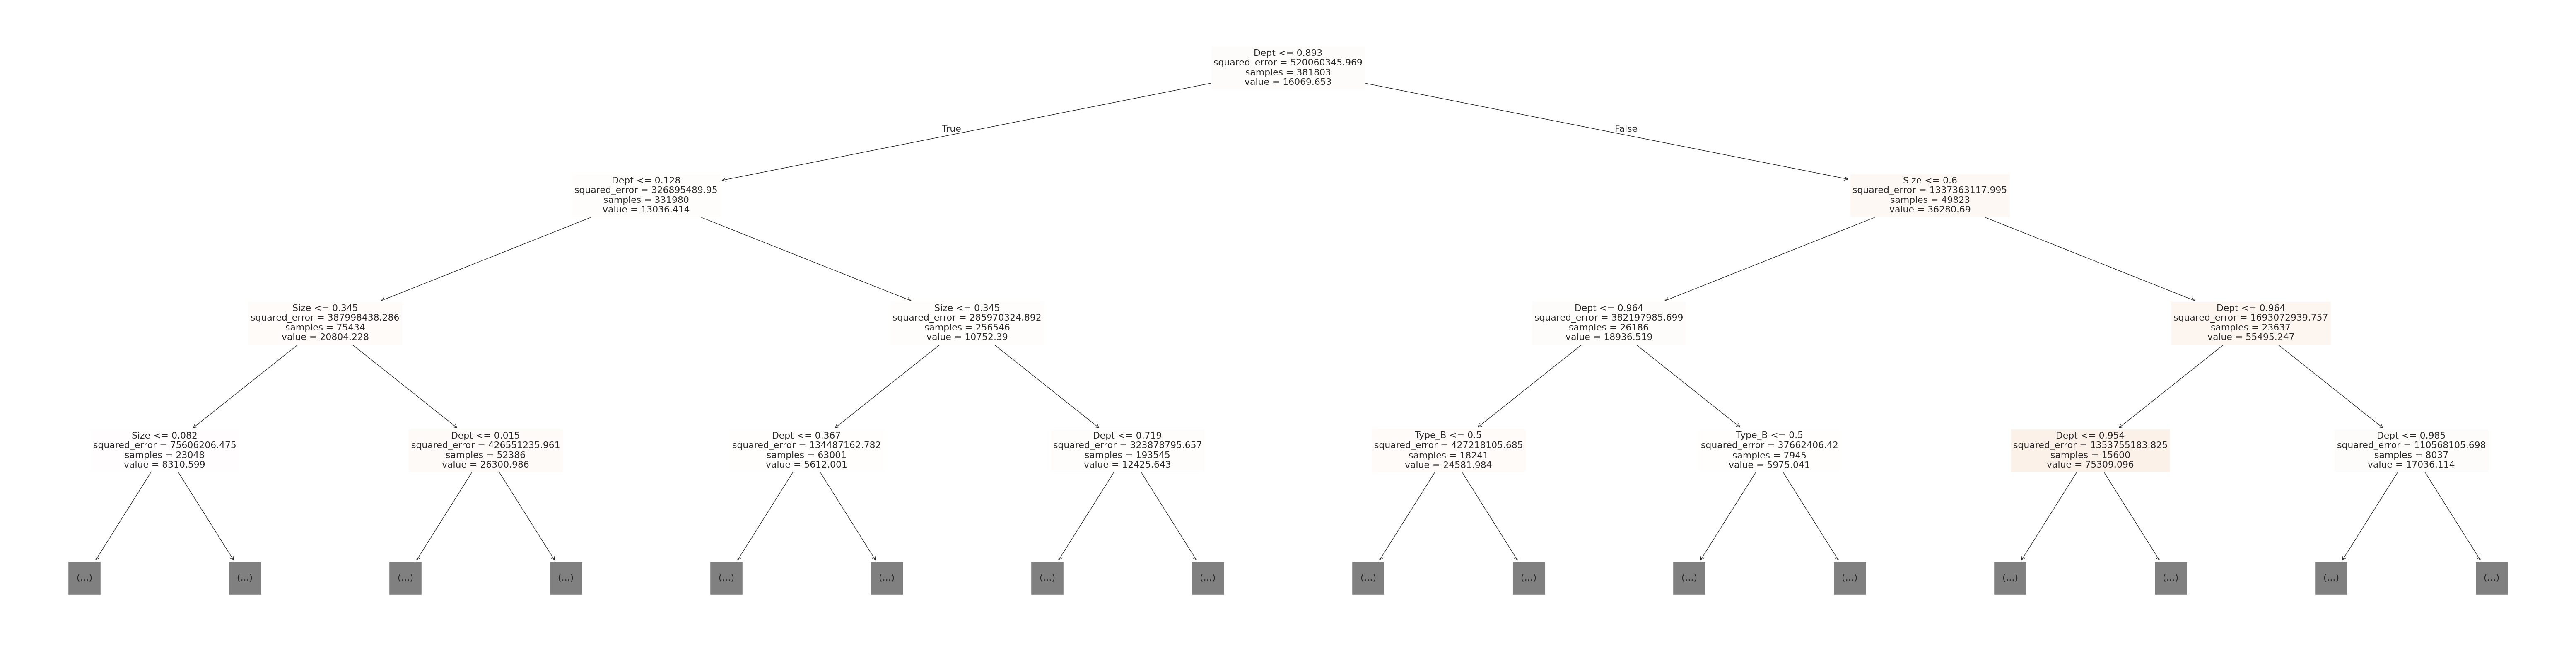

In [ ]:
plt.figure(figsize=(80, 20))
plot_tree(tree, feature_names=numeric_cols+encoded_col, filled=True, max_depth=3)

Let us proceed to the random forest.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
try_model(rf)

CPU times: user 5min 8s, sys: 2.04 s, total: 5min 10s
Wall time: 3min 13s


(np.float64(572.7102215147014), np.float64(1546.2756663355694))

Let us try to tune hyperparameters to see if we can get better results

In [ ]:
?DecisionTreeRegressor

In [ ]:
?RandomForestRegressor

Object `RandomForestRegressor` not found.


In [ ]:
tree.tree_.max_depth

46

In [ ]:
tree = DecisionTreeRegressor(random_state=42, max_depth=35)
try_model(tree)

(np.float64(2.5909331072506534), np.float64(2038.9979089086569))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, max_depth=30)
try_model(tree)

(np.float64(23.284830845216206), np.float64(2028.7797181737167))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, max_depth=25)
try_model(tree)

(np.float64(164.40429692677236), np.float64(2014.6567318627117))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, max_depth=20)
try_model(tree)

(np.float64(700.7495798249342), np.float64(1964.4152760079935))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, max_depth=15)
try_model(tree)

(np.float64(1931.7521525524369), np.float64(2261.222594794629))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, max_depth=10)
try_model(tree)

(np.float64(4513.353324747247), np.float64(4175.869182415546))

It is seen in all of these that twenty is the best max_depth for this because at the max_depth of 46 which was the initial max_depth it had $5.55 \times 10^{-20}$ as its training error. While this seems good (max_depth=46), it shows that it did not learn patterns for the training, it just memorized the training set answers.

At 20, we see that there was an increase from $5.55 \times 10^{-20}$ to 700 dollars. While this might seem wrong, it is absolutely right. It is right because the model (tree) is now deep enough to capture holiday/departmental patterns, and at the same time constrained enough to generalize well. It does not just memorize training set answers.

As the max_depth gets increased (25, 30, 35), we see that it starts memorizing the training set data and starts performing poorly for validation data, and starts performing incredibly too well for the training data (it drops from 164 dollars to 23 dollars and then to 2 dollars).

The training starts getting close to $5.55 \times 10^{-20}$ which is very unrealistic in real-life, and the validation error starts increasing which is terrible because our aim is to reduce its error.

In [ ]:
tree = DecisionTreeRegressor(random_state=42, min_samples_split= 5)
try_model(tree)

(np.float64(515.1366112675768), np.float64(2015.5257295253828))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, min_samples_split= 10)
try_model(tree)

(np.float64(868.0959005885062), np.float64(1955.2274434407102))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, min_samples_split= 15)
try_model(tree)

(np.float64(1073.2395422810118), np.float64(1920.7175700485723))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, min_samples_split= 20)
try_model(tree)

(np.float64(1208.2388746641896), np.float64(1895.7098309822475))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, min_samples_split= 25)
try_model(tree)

(np.float64(1316.5731700253084), np.float64(1877.0167320136322))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, min_samples_split= 30)
try_model(tree)

(np.float64(1402.0249606377627), np.float64(1869.0463953317062))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, min_samples_split= 35)
try_model(tree)

(np.float64(1481.5544261157752), np.float64(1878.0758012679778))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, min_samples_split= 40)
try_model(tree)

(np.float64(1534.3774487719163), np.float64(1876.511323262884))

We see here that increasing the min_samples_split from its  deafult value(2) to 40 takes the training error from $5.5 \times 10^{-20}$ dollars to 1534 dollars but does the reverse for validation error. The validation errror does decrease smoothly until it gets to 35. We see that from 30 t0 35 there is an increase and at that point underfitting starts and then the validation error drops again from 35 to 40 which is the error bouncing around blindly. We also see that moving the min_samples_split from 2 to 30 shaves off 176 dollars off the validation error. We can also clearly see that min_samples_split = 30 is the sweet spot because at that point we have the least validation error.


In [ ]:
tree = DecisionTreeRegressor(random_state=42, min_samples_leaf= 3)
try_model(tree)

(np.float64(939.6878761618002), np.float64(1921.9783462122873))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, min_samples_leaf= 5)
try_model(tree)

(np.float64(1227.1168672034619), np.float64(1898.292651588297))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, min_samples_leaf= 10)
try_model(tree)

(np.float64(1545.3761653093807), np.float64(1882.3803269588543))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, min_samples_leaf= 15)
try_model(tree)

(np.float64(1723.0722969478884), np.float64(1896.0025117100067))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, min_samples_leaf= 20)
try_model(tree)

(np.float64(1834.7699039590893), np.float64(1927.709179705832))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, min_samples_leaf= 25)
try_model(tree)

(np.float64(1940.086859738194), np.float64(1992.152676513095))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, min_samples_leaf= 30)
try_model(tree)

(np.float64(2005.5507803807857), np.float64(2010.365863527322))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, min_samples_leaf= 35)
try_model(tree)

(np.float64(2094.153125049661), np.float64(2076.4052896447097))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, min_samples_leaf= 40)
try_model(tree)

(np.float64(2147.3876330560793), np.float64(2116.793034808118))

We can see the training error increase from $5.5 \times 10^{-20}$ dollars(which was at the default min_samples_leaf(1)) to 2147 dollars(min_samples_leaf=40). The validation error too was decreasing till it got to a min_samples_leaf of 15 where it climbed up to 1896 dollars and from there it kept increasing, which is a terrible one for the validation error because our aim is to make it as low as possible. The perfect spot for this is min_samples of 10, because at 10, we have the lowest value for the validation error before underfitting starts at min_samples_leaf of 15. Also, another observation we can find here is that at min_samples_leaf of 35(validation_error=2076 dollars), the tree starts underfitting heavily because at 35 it supercedes 2045 dollars which was the was the start value i.e where min_samples_leaf was at its default(1) and it is also at this default value that we had severe overfitting($5.5 \times 10^{-20}$ dollars).

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=100)
try_model(rf)

CPU times: user 7min 26s, sys: 3.65 s, total: 7min 29s
Wall time: 4min 20s


(np.float64(572.7102215147014), np.float64(1546.2756663355694))

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=20)
try_model(rf)

CPU times: user 1min 29s, sys: 522 ms, total: 1min 29s
Wall time: 51 s


(np.float64(605.4075047786324), np.float64(1582.7567022911398))

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=150)
try_model(rf)

CPU times: user 11min 9s, sys: 4.1 s, total: 11min 13s
Wall time: 6min 27s


(np.float64(570.7949562629851), np.float64(1542.5148729621594))

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=200)
try_model(rf)

CPU times: user 14min 59s, sys: 11.2 s, total: 15min 11s
Wall time: 8min 45s


(np.float64(568.925808425079), np.float64(1541.4124593725742))

 We can see from this that increasing the n_estimators(150, 200) drops the errors which is a good one and that reducing the n_estimators(20) raises the errors which is a bad one.

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1, max_depth=20)
try_model(rf)

CPU times: user 6min 2s, sys: 1.71 s, total: 6min 4s
Wall time: 3min 29s


(np.float64(914.1116900032489), np.float64(1597.6511515559998))

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1, max_depth=15)
try_model(rf)

CPU times: user 4min 32s, sys: 458 ms, total: 4min 33s
Wall time: 2min 37s


(np.float64(1865.125745772148), np.float64(2047.0778113502406))

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1, max_depth=10)
try_model(rf)

CPU times: user 3min 8s, sys: 263 ms, total: 3min 8s
Wall time: 1min 47s


(np.float64(4280.6928150339645), np.float64(3955.0389732422077))

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1, max_depth=25)
try_model(rf)

CPU times: user 6min 59s, sys: 5.61 s, total: 7min 4s
Wall time: 4min 4s


(np.float64(631.1807397621433), np.float64(1547.6498524375152))

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1, max_depth=30)
try_model(rf)

CPU times: user 7min 21s, sys: 4.51 s, total: 7min 25s
Wall time: 4min 15s


(np.float64(578.1382030265826), np.float64(1543.4709444014686))

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1, max_depth=35)
try_model(rf)

CPU times: user 7min 23s, sys: 2.55 s, total: 7min 26s
Wall time: 4min 15s


(np.float64(573.1816412069522), np.float64(1546.6818195357903))

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1, max_depth=40)
try_model(rf)

CPU times: user 7min 23s, sys: 2.51 s, total: 7min 26s
Wall time: 4min 15s


(np.float64(572.5841774766923), np.float64(1545.4516889050296))

We can see that the farther away(max_depth = (20, 15, 10)) from the tree's max_depth(46), the worse or better still the more the increase in the errors which is a bad one. And that also, the closer(max_depth = (30, 35, 40)) it is to the tree's max_depth(46), the more the decrease in the errors which is a good one.

Let us try min_samples_split

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1, min_samples_split=3)
try_model(rf)

CPU times: user 6min 59s, sys: 2.46 s, total: 7min 1s
Wall time: 4min 1s


(np.float64(627.4113056230256), np.float64(1547.175272396128))

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1, min_samples_split=5)
try_model(rf)

CPU times: user 6min 33s, sys: 1.18 s, total: 6min 34s
Wall time: 3min 45s


(np.float64(760.2026868501099), np.float64(1554.2919005288998))

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1, min_samples_split=10)
try_model(rf)

CPU times: user 6min 13s, sys: 956 ms, total: 6min 14s
Wall time: 3min 36s


(np.float64(1006.5174858323419), np.float64(1570.5614320364746))

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1, min_samples_split=15)
try_model(rf)

CPU times: user 5min 47s, sys: 464 ms, total: 5min 47s
Wall time: 3min 19s


(np.float64(1162.387031243708), np.float64(1583.4101668320975))

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1, min_samples_split=20)
try_model(rf)

CPU times: user 5min 37s, sys: 506 ms, total: 5min 38s
Wall time: 3min 13s


(np.float64(1279.444069214642), np.float64(1601.287159486058))

For min_samples_split, it is better left at its default value.

Let us try min_samples_leaf

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1, min_samples_leaf=3)
try_model(rf)

CPU times: user 6min 5s, sys: 814 ms, total: 6min 6s
Wall time: 3min 30s


(np.float64(1022.6586735715429), np.float64(1573.6514775077926))

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1, min_samples_leaf=5)
try_model(rf)

CPU times: user 5min 40s, sys: 480 ms, total: 5min 41s
Wall time: 3min 14s


(np.float64(1259.3440512396858), np.float64(1607.8834592947176))

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1, min_samples_leaf=7)
try_model(rf)

CPU times: user 5min 27s, sys: 474 ms, total: 5min 27s
Wall time: 3min 7s


(np.float64(1407.6777986681548), np.float64(1636.1592187557674))

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1, min_samples_leaf=20)
try_model(rf)

CPU times: user 4min 52s, sys: 446 ms, total: 4min 52s
Wall time: 2min 48s


(np.float64(1857.3258910080165), np.float64(1822.912550990505))

The same applies to min_samples_leaf. I mean that increasing it from its default value only gets worse(giving higher training and val errors) just like
min_samples_split.

Now let me try to use max_feature

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1, max_features=0.6)
try_model(rf)

CPU times: user 4min 19s, sys: 7 s, total: 4min 26s
Wall time: 2min 36s


(np.float64(642.6306753586706), np.float64(1600.3648678583513))

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1, max_features=0.8)
try_model(rf)

CPU times: user 5min 59s, sys: 9.19 s, total: 6min 8s
Wall time: 3min 39s


(np.float64(572.2781086420939), np.float64(1505.921569062643))

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1, max_features=0.9)
try_model(rf)

CPU times: user 6min 31s, sys: 2.77 s, total: 6min 34s
Wall time: 3min 44s


(np.float64(568.0305697323926), np.float64(1509.0505288154145))

For the max_features we see that moving the values slightly from 1(0.9, 0.8) which is the default value decreases the error and that is a very good sign.
Now let me combine the hyperparameters that worked.

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1, max_features=0.9, n_estimators=200, max_depth=40)
try_model(rf)

CPU times: user 13min 10s, sys: 14.5 s, total: 13min 24s
Wall time: 7min 47s


(np.float64(564.4779360428407), np.float64(1502.1884157828708))

In combining the best tuning values for the hyperparameters, we see a significant drop in the errors which is a very very good sign.

In [ ]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

In [ ]:
importance_df.head(10)

,feature,importance
1,Dept,0.630691
3,Size,0.187221
0,Store,0.055995
10,CPI,0.030695
12,Week,0.025316
17,Is_Thanksgiving,0.019740
11,Unemployment,0.012545
22,Type_B,0.010584
19,Is_Pre_Christmas,0.010347
21,Type_A,0.003424


We see here that Size and Dept have very strong impact on the randomforest's results.